### Train Pipeline

### 1. Set Kernel Env

In [1]:
%load_ext autoreload
%autoreload 2

import sys

sys.path.insert(0, '/home/gorelova_i_v/projects/cvm_churn-from-dac_binary-class_churn-dac/src')

from datetime import datetime

import os
from pathlib import Path
import joblib
from collections import defaultdict
from tqdm.auto import tqdm

import logging
logger = logging.getLogger()
logger.setLevel(logging.INFO)

import magpie.sql_utils as su

import pandas as pd
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 200)

import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from catboost import CatBoostClassifier

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_predict
from sklearn.calibration import calibration_curve
from sklearn.linear_model import LogisticRegression
from sklearn.isotonic import IsotonicRegression
from sklearn.preprocessing import SplineTransformer
from sklearn.pipeline import make_pipeline
from sklearn.inspection import permutation_importance

import shap

from sklearn.metrics import (
    average_precision_score as sk_average_precision_score,
    roc_auc_score as sk_roc_auc_score,
    roc_curve,
    precision_recall_curve,
    PrecisionRecallDisplay,
    confusion_matrix as sk_confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    brier_score_loss as sk_brier_score_loss,
)

from cvm_ml_metrics.classification import (
    roc_auc_score,
    precision_recall_auc,
    confusion_matrix,
    log_loss,
    recall_score,
    precision_score,
    sensitivity_specificity,
    balanced_accuracy,
    f1_score,
    fbeta_score,
    brier_score_loss,
    youden_j,
    markedness,
    lift,
    gini,
    ks_stat_bin_class,
    ece_mce_fast,
    matthews_corrcoef,
    cohen_kappa_score,
)

import mlflow
from mlflow import MlflowClient
from mlflow.models.signature import infer_signature

/home/gorelova_i_v/.local/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from cvm_model.io import State
import cvm_model.functions as func
import cvm_model.utils as utils
from cvm_model.parameters import (
    RANDOM_STATE,
    template,
    features,
    target,
    score,
    project_name,
    model_type,
    train_data_stat_suffix,
    artifacts_dir,
    jira,
    threshold,
)

# Path(artifacts_dir).mkdir(parents=True, exist_ok=True)

In [3]:
event_timestamp = datetime(2026, 1, 1)

base_month = event_timestamp.date().replace(day=1).isoformat()
target_month = (pd.Timestamp(base_month) + pd.DateOffset(months=1)).date().isoformat()
feature_date = target_month

print('target:', target)
print('features:', len(features))

target: target_churn_from_dac
features: 80


### 2. State and Connections

In [4]:
spark.stop()
state = State.from_env()
engine = state.credentials.loyalty_gp.sa_engine
s3 = su.get_s3_client()

2026-05-25 11:00:36,402 WARN cluster.YarnSchedulerBackend$YarnSchedulerEndpoint: Attempted to request executors before the AM has registered!


### 3. Load Dataset

In [5]:
train_df = pd.read_parquet(f'train_{base_month}.parquet')
test_df = pd.read_parquet(f'test_{base_month}.parquet')

df = train_df.copy().reset_index(drop=True)
holdout_df = test_df.copy().reset_index(drop=True)

print('df:', train_df.shape)
print('holdout_df:', test_df.shape)

display(df.head())

df: (796960, 160)
holdout_df: (199240, 160)


,contact_id,target_churn_from_dac,cheque_recency,login_recency,omni_qr_recency,omni_features_recency,perf_recency,rto_24,trans_count_24,aov_24,trans_lag_avg_24,whs_count_24,format_count_24,location_count_24,whs_age_avg_24,whs_is_closed_avg_24,whs_in_capital_avg_24,whs_in_city_avg_24,population_avg_24,square_trade_avg_24,competitor_echelon_avg_24,competitor_age_avg_24,competitor_dist_avg_24,rto_12,trans_count_12,aov_12,trans_lag_avg_12,rto_6,trans_count_6,aov_6,trans_lag_avg_6,rto_3,trans_count_3,aov_3,trans_lag_avg_3,rto_2,trans_count_2,aov_2,trans_lag_avg_2,rto_1,trans_count_1,aov_1,trans_lag_avg_1,login_count_24,login_lag_avg_24,login_count_12,login_lag_avg_12,login_count_6,login_lag_avg_6,login_count_3,login_lag_avg_3,login_count_2,login_lag_avg_2,login_count_1,login_lag_avg_1,omni_qr_days_count_24,omni_qr_lag_avg_24,omni_qr_days_count_12,omni_qr_lag_avg_12,omni_qr_days_count_6,omni_qr_lag_avg_6,omni_qr_days_count_3,omni_qr_lag_avg_3,omni_qr_days_count_2,omni_qr_lag_avg_2,omni_qr_days_count_1,omni_qr_lag_avg_1,omni_features_days_count_24,omni_features_lag_avg_24,omni_features_days_count_12,omni_features_lag_avg_12,omni_features_days_count_6,omni_features_lag_avg_6,omni_features_days_count_3,omni_features_lag_avg_3,omni_features_days_count_2,omni_features_lag_avg_2,omni_features_days_count_1,omni_features_lag_avg_1,omni_fav_features_days_count_24,omni_fav_features_days_count_12,omni_fav_features_days_count_6,omni_fav_features_days_count_3,omni_fav_features_days_count_2,omni_fav_features_days_count_1,omni_unique_features_count_24,omni_unique_features_count_12,omni_unique_features_count_6,omni_unique_features_count_3,omni_unique_features_count_2,omni_unique_features_count_1,omni_goals_activated_count_12,omni_goals_updated_count_12,omni_goals_finished_count_12,omni_goals_activated_count_6,omni_goals_updated_count_6,omni_goals_finished_count_6,omni_goals_activated_count_3,omni_goals_updated_count_3,omni_goals_finished_count_3,omni_goals_activated_count_2,omni_goals_updated_count_2,omni_goals_finished_count_2,omni_goals_activated_count_1,omni_goals_updated_count_1,omni_goals_finished_count_1,accept_count_24,accept_count_12,accept_count_6,accept_count_3,accept_count_2,accept_count_1,bonus_accrued_sum_24,bonus_accrued_offer_sum_24,bonus_expired_sum_24,bonus_redeemed_sum_24,bonus_accrued_sum_12,bonus_accrued_offer_sum_12,bonus_expired_sum_12,bonus_redeemed_sum_12,bonus_accrued_sum_6,bonus_accrued_offer_sum_6,bonus_expired_sum_6,bonus_redeemed_sum_6,bonus_accrued_sum_3,bonus_accrued_offer_sum_3,bonus_expired_sum_3,bonus_redeemed_sum_3,bonus_accrued_sum_2,bonus_accrued_offer_sum_2,bonus_expired_sum_2,bonus_redeemed_sum_2,bonus_accrued_sum_1,bonus_accrued_offer_sum_1,bonus_expired_sum_1,bonus_redeemed_sum_1,avg_level_24,avg_level_12,avg_level_6,avg_level_3,avg_level_2,avg_level_1,transaction_tendency,login_tendency,omni_qr_tendency,omni_features_tendency,dac_age_months,cust_age_years,is_male,dac_months_count,dac_months_last_3,dac_months_last_6,dac_months_last_12,dac_months_per_dac_age_ratio,dac_share_last_12,is_stable_dac,is_regular_dac,is_unstable_dac,is_new_dac,dac_segment_12m
0,52367591,0,5.0,5.0,5.0,41.0,33.0,142396.0,94.0,1514.850,7.54839,7.0,4.0,3.0,10.69150,0.000000,0.000000,0.882979,498762.0,467.098,1.15957,4.01418,266.429,82413.1,49.0,1681.900,7.47917,50337.10,27.0,1864.340,6.26923,32177.90,18.0,1787.660,4.94118,21611.60,13.0,1662.430,4.25000,13000.90,7.0,1857.280,4.16667,92.0,7.90110,52.0,7.03922,30.0,5.62069,17.0,5.25000,12.0,5.09091,5.0,6.25000,70.0,8.66667,46.0,7.97778,24.0,7.08696,15.0,6.00000,11.0,5.10000,5.0,6.25000,16.0,44.40000,11.0,32.30000,6.0,23.20,2.0,48.0000,1.0,NaN,0.0,NaN,12.0,9.0,5.0,2.0,1.0,0.0,3.0,3.0,2.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,26.0,12.0,0.0,0.0,0.0,0.0,2347.90,60.40,1179.67,0.0,1654.43,60.4,540.67,0.0,819.70,60.4,194.0,0.0,576.75,39.4,80.0,0.0,463.95,13.4,80.0,0.0,130.00,0.0,80.0,0.0,1.65,1.75000,1.83333,2.00000,2.5,2.0,0.662393,0.632823,0.576923,0.923423,49.

### 4. Stratification Segments

In [6]:
df['segment'] = df['dac_segment_12m'].astype(str)
holdout_df['segment'] = holdout_df['dac_segment_12m'].astype(str)

df['strat'] = df['segment'].astype(str) + '_' + df[target].astype(str)
holdout_df['strat'] = holdout_df['segment'].astype(str) + '_' + holdout_df[target].astype(str)

strat_counts = df['strat'].value_counts()
if (strat_counts < 5).any():
    print('Only target for CV stratification')
    df['strat'] = df[target].astype(str)

### 5. Load Chosen Features

In [8]:
recency_cols = [
    'cheque_recency',
    'login_recency',
    'omni_qr_recency',
    'omni_features_recency',
    'perf_recency',
]
for col in recency_cols:
    if col in df.columns:
        df[col] = df[col].fillna(999)
    if holdout_df is not None and col in holdout_df.columns:
        holdout_df[col] = holdout_df[col].fillna(999)

### 6. Choose Model

In [9]:
best_params = {

}

model = CatBoostClassifier(
    random_state=RANDOM_STATE,
    use_best_model=True,
    metric_period=20,
    eval_metric='PRAUC',
    eval_fraction=0.1,
    early_stopping_rounds=50,
    thread_count=-1
    # auto_class_weights='Balanced',
    # **best_params,
)
model

CatBoostClassifier(early_stopping_rounds=50, eval_fraction=0.1, eval_metric='PRAUC', metric_period=20, random_state=42, use_best_model=True)

### 7. Train With Crossvalidation

In [10]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

df[['class_0', score]] = cross_val_predict(
    model,
    df[features],
    df[target],
    cv=skf.split(df[features], df['strat']),
    method='predict_proba',
)

print(df[[target, score]].head())
print('OOF PR-AUC:', sk_average_precision_score(df[target], df[score]))

Learning rate set to 0.152169


0:	learn: 0.4946601	test: 0.4924064	best: 0.4924064 (0)	total: 163ms	remaining: 2m 42s
20:	learn: 0.5388512	test: 0.5336509	best: 0.5336509 (20)	total: 941ms	remaining: 43.9s
40:	learn: 0.5460205	test: 0.5399356	best: 0.5399356 (40)	total: 1.83s	remaining: 42.7s
60:	learn: 0.5497598	test: 0.5422620	best: 0.5422620 (60)	total: 2.61s	remaining: 40.2s
80:	learn: 0.5533778	test: 0.5440033	best: 0.5440033 (80)	total: 3.44s	remaining: 39s
100:	learn: 0.5565666	test: 0.5445474	best: 0.5445474 (100)	total: 4.15s	remaining: 36.9s
120:	learn: 0.5599182	test: 0.5451146	best: 0.5452506 (119)	total: 4.88s	remaining: 35.4s
140:	learn: 0.5627280	test: 0.5455581	best: 0.5456540 (137)	total: 5.7s	remaining: 34.7s
160:	learn: 0.5659725	test: 0.5456364	best: 0.5456673 (147)	total: 6.4s	remaining: 33.3s
180:	learn: 0.5686202	test: 0.5458936	best: 0.5459161 (175)	total: 7.1s	remaining: 32.1s
200:	learn: 0.5714539	test: 0.5459028	best: 0.5459952 (196)	total: 7.81s	remaining: 31s
220:	learn: 0.5739504	test: 

20:	learn: 0.5407815	test: 0.5294980	best: 0.5294980 (20)	total: 785ms	remaining: 36.6s
40:	learn: 0.5470193	test: 0.5340738	best: 0.5340738 (40)	total: 1.49s	remaining: 35s
60:	learn: 0.5515907	test: 0.5374322	best: 0.5374475 (59)	total: 2.19s	remaining: 33.7s
80:	learn: 0.5548575	test: 0.5394455	best: 0.5394455 (80)	total: 2.93s	remaining: 33.2s
100:	learn: 0.5580211	test: 0.5406954	best: 0.5407435 (99)	total: 3.66s	remaining: 32.6s
120:	learn: 0.5617762	test: 0.5408079	best: 0.5408888 (107)	total: 4.35s	remaining: 31.6s
140:	learn: 0.5651642	test: 0.5416358	best: 0.5416358 (140)	total: 5.09s	remaining: 31s
160:	learn: 0.5682639	test: 0.5424394	best: 0.5425787 (156)	total: 5.82s	remaining: 30.3s
180:	learn: 0.5712534	test: 0.5423676	best: 0.5427629 (168)	total: 6.56s	remaining: 29.7s
200:	learn: 0.5741928	test: 0.5424258	best: 0.5427629 (168)	total: 7.27s	remaining: 28.9s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.5427628754
bestIteration = 168

Shrink model 

20:	learn: 0.5401061	test: 0.5380939	best: 0.5380939 (20)	total: 796ms	remaining: 37.1s
40:	learn: 0.5471174	test: 0.5438017	best: 0.5438017 (40)	total: 1.5s	remaining: 35.2s
60:	learn: 0.5514462	test: 0.5458526	best: 0.5458526 (60)	total: 2.3s	remaining: 35.4s
80:	learn: 0.5543625	test: 0.5468802	best: 0.5468802 (80)	total: 3s	remaining: 34s
100:	learn: 0.5577968	test: 0.5473545	best: 0.5474253 (99)	total: 3.69s	remaining: 32.8s
120:	learn: 0.5609832	test: 0.5473849	best: 0.5474653 (106)	total: 4.38s	remaining: 31.8s
140:	learn: 0.5641689	test: 0.5473816	best: 0.5475349 (122)	total: 5.08s	remaining: 30.9s
160:	learn: 0.5669730	test: 0.5476018	best: 0.5478356 (155)	total: 5.76s	remaining: 30s
180:	learn: 0.5703218	test: 0.5476455	best: 0.5478356 (155)	total: 6.48s	remaining: 29.3s
200:	learn: 0.5730459	test: 0.5476467	best: 0.5478356 (155)	total: 7.18s	remaining: 28.5s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.5478355764
bestIteration = 155

Shrink model to fi

20:	learn: 0.5402491	test: 0.5399699	best: 0.5399699 (20)	total: 760ms	remaining: 35.4s
40:	learn: 0.5472224	test: 0.5436839	best: 0.5436839 (40)	total: 1.47s	remaining: 34.4s
60:	learn: 0.5515872	test: 0.5454347	best: 0.5454347 (60)	total: 2.18s	remaining: 33.6s
80:	learn: 0.5544145	test: 0.5468196	best: 0.5468196 (80)	total: 2.9s	remaining: 32.9s
100:	learn: 0.5578631	test: 0.5470058	best: 0.5472089 (93)	total: 3.58s	remaining: 31.9s
120:	learn: 0.5608404	test: 0.5472231	best: 0.5473581 (109)	total: 4.28s	remaining: 31.1s
140:	learn: 0.5636699	test: 0.5478223	best: 0.5478320 (139)	total: 4.97s	remaining: 30.3s
160:	learn: 0.5667062	test: 0.5476252	best: 0.5480042 (147)	total: 5.67s	remaining: 29.5s
180:	learn: 0.5696933	test: 0.5477388	best: 0.5480042 (147)	total: 6.39s	remaining: 28.9s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.5480042193
bestIteration = 147

Shrink model to first 148 iterations.
Learning rate set to 0.152169
0:	learn: 0.4938708	test: 0.4973

20:	learn: 0.5385456	test: 0.5413052	best: 0.5413052 (20)	total: 767ms	remaining: 35.8s
40:	learn: 0.5458081	test: 0.5457387	best: 0.5457387 (40)	total: 1.48s	remaining: 34.6s
60:	learn: 0.5500490	test: 0.5474274	best: 0.5474274 (60)	total: 2.2s	remaining: 33.9s
80:	learn: 0.5533346	test: 0.5478278	best: 0.5478863 (79)	total: 2.92s	remaining: 33.1s
100:	learn: 0.5571617	test: 0.5482808	best: 0.5482808 (100)	total: 3.64s	remaining: 32.4s
120:	learn: 0.5605399	test: 0.5479416	best: 0.5484279 (109)	total: 4.34s	remaining: 31.5s
140:	learn: 0.5639632	test: 0.5479332	best: 0.5484279 (109)	total: 5.02s	remaining: 30.6s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.5484278661
bestIteration = 109

Shrink model to first 110 iterations.
   target_churn_from_dac     score
0                      0  0.020245
1                      0  0.006420
2                      0  0.001296
3                      0  0.225225
4                      0  0.100704
OOF PR-AUC: 0.5473813080093389


In [11]:
metrics_cv = []
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
X = df[features]
y = df[target]
z = df['strat']

predicts = np.zeros(len(df))

for i, (train_idx, val_idx) in enumerate(skf.split(X, z), start=1):
    X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
    X_val, y_val = X.iloc[val_idx], y.iloc[val_idx]

    print()
    print(f'Training fold {i}...')
    fold_model = CatBoostClassifier(**model.get_params())
    fold_model.fit(X_train, y_train, plot=False, verbose=0)

    print(f'Scoring fold {i}...')
    predicts[val_idx] = fold_model.predict_proba(X_val)[:, 1]

    ap_gain = sk_average_precision_score(y_val, predicts[val_idx]) - y_val.mean()
    metrics_cv.append(ap_gain)
    print(f'Fold {i} complete. AP gain = {ap_gain:.6f}')

print('AP gain by folds:', metrics_cv)
print('AP gain mean:', np.mean(metrics_cv), 'std:', np.std(metrics_cv))

df[score] = predicts


Training fold 1...


Scoring fold 1...
Fold 1 complete. AP gain = 0.389992

Training fold 2...


Scoring fold 2...
Fold 2 complete. AP gain = 0.384155

Training fold 3...


Scoring fold 3...
Fold 3 complete. AP gain = 0.384173

Training fold 4...


Scoring fold 4...
Fold 4 complete. AP gain = 0.386531

Training fold 5...


Scoring fold 5...
Fold 5 complete. AP gain = 0.387741
AP gain by folds: [0.3899922141898174, 0.3841553666322946, 0.3841725927527318, 0.38653145409998574, 0.38774077758438913]
AP gain mean: 0.3865184810518437 std: 0.002220292804974073


### 8. Train Final Model And Score Holdout

In [12]:
model.fit(df[features], df[target], plot=False, verbose=1)

df[f'{score}_full_model'] = model.predict_proba(df[features])[:, 1]

if holdout_df is not None:
    holdout_df[score] = model.predict_proba(holdout_df[features])[:, 1]
    print('Holdout scored:', holdout_df.shape)
    display(holdout_df[[target, score]].head())

Learning rate set to 0.160791
0:	learn: 0.4991590	test: 0.4972757	best: 0.4972757 (0)	total: 118ms	remaining: 1m 57s


20:	learn: 0.5392403	test: 0.5383416	best: 0.5383416 (20)	total: 1.03s	remaining: 48.2s
40:	learn: 0.5457445	test: 0.5429241	best: 0.5429241 (40)	total: 2.04s	remaining: 47.6s
60:	learn: 0.5498316	test: 0.5444608	best: 0.5444608 (60)	total: 3s	remaining: 46.3s
80:	learn: 0.5528723	test: 0.5453383	best: 0.5454040 (79)	total: 3.99s	remaining: 45.2s
100:	learn: 0.5561627	test: 0.5457255	best: 0.5457613 (96)	total: 4.95s	remaining: 44.1s
120:	learn: 0.5592010	test: 0.5462829	best: 0.5462829 (120)	total: 5.92s	remaining: 43s
140:	learn: 0.5618611	test: 0.5467073	best: 0.5467073 (140)	total: 6.89s	remaining: 42s
160:	learn: 0.5645389	test: 0.5464931	best: 0.5468529 (146)	total: 7.83s	remaining: 40.8s
180:	learn: 0.5670556	test: 0.5465686	best: 0.5468529 (146)	total: 8.76s	remaining: 39.6s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.5468529069
bestIteration = 146

Shrink model to first 147 iterations.
Holdout scored: (199240, 163)


,target_churn_from_dac,score
0,0,0.117669
1,0,0.557682
2,0,0.109677
3,0,0.045596
4,0,0.026629


In [13]:
model_path = 'final_model_churn_from_dac.cbm'
model.save_model(str(model_path))
print(model_path)

final_model_churn_from_dac.cbm


### 9. Calibrate With Crossvalidation

In [14]:
platt = LogisticRegression(C=1e10)
platt_spline = make_pipeline(SplineTransformer(n_knots=5, degree=3), LogisticRegression(C=1.0))
isotonic = IsotonicRegression(out_of_bounds='clip')

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
X_score = pd.DataFrame(df[score])
y = df[target]
z = df['strat']

X_scored = pd.DataFrame(index=df.index)

for i, (train_idx, val_idx) in enumerate(skf.split(X_score, z), start=1):
    X_train, y_train = X_score.iloc[train_idx], y.iloc[train_idx]
    X_val = X_score.iloc[val_idx]

    print(f'Calibrating on fold {i}...')
    platt.fit(X_train, y_train)
    platt_spline.fit(X_train, y_train)
    isotonic.fit(X_train, y_train)

    X_scored.loc[X_val.index, f'{score}_platt'] = platt.predict_proba(X_val)[:, 1]
    X_scored.loc[X_val.index, f'{score}_platt_spline'] = platt_spline.predict_proba(X_val)[:, 1]
    X_scored.loc[X_val.index, f'{score}_isotonic'] = isotonic.transform(X_val[score])

df[[f'{score}_platt', f'{score}_platt_spline', f'{score}_isotonic']] = X_scored[[f'{score}_platt', f'{score}_platt_spline', f'{score}_isotonic']]
df[[score, f'{score}_platt', f'{score}_platt_spline', f'{score}_isotonic']].describe()

Calibrating on fold 1...
Calibrating on fold 2...
Calibrating on fold 3...
Calibrating on fold 4...
Calibrating on fold 5...


,score,score_platt,score_platt_spline,score_isotonic
count,796960.000000,796960.000000,796960.000000,796960.000000
mean,0.160920,0.161025,0.160976,0.160948
std,0.195216,0.200147,0.194749,0.194837
min,0.000552,0.039159,0.007115,0.000000
25%,0.011621,0.042128,0.011326,0.010537
50%,0.069397,0.060479,0.060619,0.070402
75%,0.256994,0.181559,0.249837,0.251992
max,0.946723,0.954988,0.845224,1.000000


### 10. Evaluate Probabilities

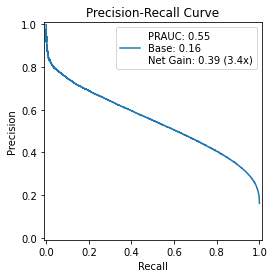

In [15]:
plt.rcParams['figure.figsize'] = [8, 6]
func.plot_precision_recall_curve(df[target], df[score])

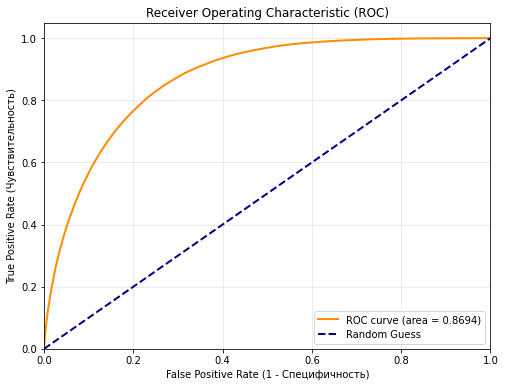

In [16]:
func.plot_roc(df[target], df[score])

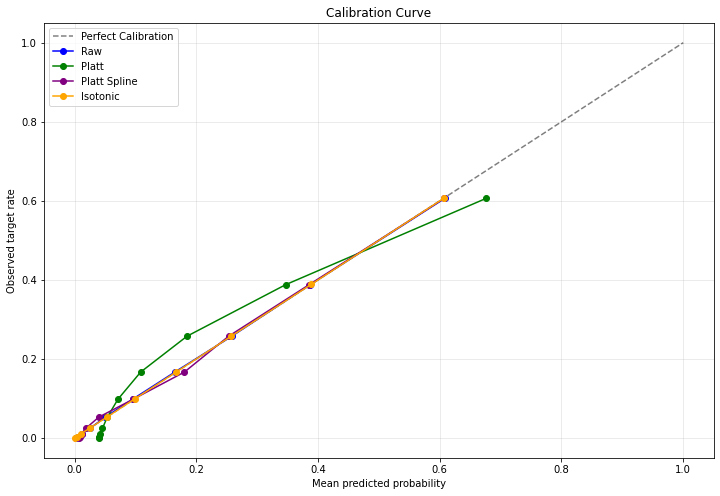

In [17]:
plt.figure(figsize=(12, 8))
plt.plot([0, 1], [0, 1], 'k--', label='Perfect Calibration', alpha=0.5)

models_to_plot = [
    (df[score], 'Raw', 'blue'),
    (df[f'{score}_platt'], 'Platt', 'green'),
    (df[f'{score}_platt_spline'], 'Platt Spline', 'purple'),
    (df[f'{score}_isotonic'], 'Isotonic', 'orange'),
]

for preds, label, color in models_to_plot:
    prob_true, prob_pred = calibration_curve(df[target], preds, n_bins=10, strategy='quantile')
    plt.plot(prob_pred, prob_true, marker='o', label=label, color=color)

plt.xlabel('Mean predicted probability')
plt.ylabel('Observed target rate')
plt.title('Calibration Curve')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

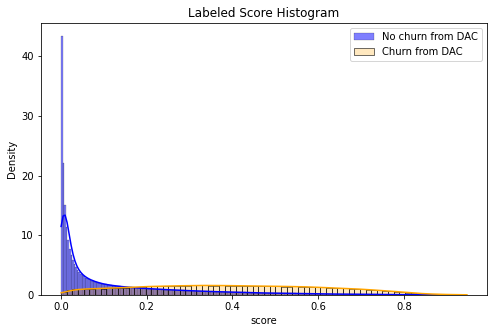

In [18]:
plt.figure(figsize=(8, 5))
sns.histplot(df[df[target] == 0][score], label='No churn from DAC', kde=True, stat='density', color='blue')
sns.histplot(df[df[target] == 1][score], label='Churn from DAC', kde=True, stat='density', alpha=0.25, color='orange')
plt.title('Labeled Score Histogram')
plt.legend();

Holdout PR-AUC: 0.5498872883695612
Holdout ROC-AUC: 0.870852884314129


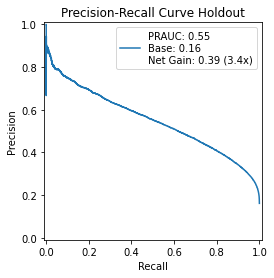

In [19]:
if holdout_df is not None:
    print('Holdout PR-AUC:', sk_average_precision_score(holdout_df[target], holdout_df[score]))
    print('Holdout ROC-AUC:', sk_roc_auc_score(holdout_df[target], holdout_df[score]))
    func.plot_precision_recall_curve(holdout_df[target], holdout_df[score], title_suffix='Holdout')

### 11. Evaluate Classes And Threshold

In [20]:
def find_threshold(y_true, y_pred, eval_function, **kwargs):
    score_by_threshold = {}
    for t in np.arange(0.05, 1, 0.05):
        y_class = y_pred > t
        score_by_threshold[t] = eval_function(y_true, y_class, **kwargs)
    return max(score_by_threshold.items(), key=lambda x: x[1])[0]


t = df[target]
s = df[score]

for beta in np.arange(0.05, 1, 0.05):
    best_t = find_threshold(t, s, fbeta_score, beta=beta)
    c_beta = s > best_t
    print(round(beta, 2), 'threshold:', round(best_t, 3), 'predicted_positive_share:', round(c_beta.mean(), 4))

0.05 threshold: 0.75 predicted_positive_share: 0.0101
0.1 threshold: 0.7 predicted_positive_share: 0.0193
0.15 threshold: 0.65 predicted_positive_share: 0.0317
0.2 threshold: 0.6 predicted_positive_share: 0.047
0.25 threshold: 0.55 predicted_positive_share: 0.0655
0.3 threshold: 0.55 predicted_positive_share: 0.0655
0.35 threshold: 0.5 predicted_positive_share: 0.087
0.4 threshold: 0.5 predicted_positive_share: 0.087
0.45 threshold: 0.45 predicted_positive_share: 0.1116
0.5 threshold: 0.45 predicted_positive_share: 0.1116
0.55 threshold: 0.4 predicted_positive_share: 0.1401
0.6 threshold: 0.4 predicted_positive_share: 0.1401
0.65 threshold: 0.35 predicted_positive_share: 0.1734
0.7 threshold: 0.35 predicted_positive_share: 0.1734
0.75 threshold: 0.35 predicted_positive_share: 0.1734
0.8 threshold: 0.35 predicted_positive_share: 0.1734
0.85 threshold: 0.3 predicted_positive_share: 0.2121
0.9 threshold: 0.3 predicted_positive_share: 0.2121
0.95 threshold: 0.3 predicted_positive_share: 0.

In [21]:
threshold_f1 = find_threshold(t, s, fbeta_score, beta=1)
threshold_f05 = find_threshold(t, s, fbeta_score, beta=0.5)
threshold_f035 = find_threshold(t, s, fbeta_score, beta=0.35)

print('threshold from parameters.py:', threshold)
print('threshold F1:', threshold_f1)
print('threshold F0.5:', threshold_f05)
print('threshold F0.35:', threshold_f035)

selected_threshold = threshold_f1
c = s > selected_threshold
print(classification_report(t, c))

threshold from parameters.py: 0.3
threshold F1: 0.3
threshold F0.5: 0.45
threshold F0.35: 0.5
              precision    recall  f1-score   support

           0       0.93      0.87      0.90    668693
           1       0.49      0.64      0.55    128267

    accuracy                           0.83    796960
   macro avg       0.71      0.76      0.73    796960
weighted avg       0.86      0.83      0.84    796960



In [22]:
metrics = {
    'ROC-AUC': roc_auc_score(t, s),
    'PR-AUC': precision_recall_auc(t, s),
    'AP gain': sk_average_precision_score(t, s) - t.mean(),
    'Log loss': log_loss(t, s),
    'Recall': recall_score(t, c),
    'Precision': precision_score(t, c),
    'Specificity': sensitivity_specificity(t, c)[1],
    'Balanced accuracy': balanced_accuracy(t, c),
    'F1': f1_score(t, c),
    'F0.5': fbeta_score(t, c, beta=0.5),
    'F2': fbeta_score(t, c, beta=2),
    'Brier score': brier_score_loss(t, s),
    'Youden j': youden_j(t, c),
    'Markedness': markedness(t, s),
    'Lift': lift(t, s),
    'Gini': gini(t, s),
    'Kolmogorov-Smirnov statistic': ks_stat_bin_class(t, s),
    'Expected Calibration Error': ece_mce_fast(t, s)[0],
    'Maximum Calibration Error': ece_mce_fast(t, s)[1],
    'Matthews corrcoef': matthews_corrcoef(t, c),
    'Cohen kappa score': cohen_kappa_score(t, c),
}

pd.DataFrame(metrics, index=['value']).T

,value
ROC-AUC,0.869439
PR-AUC,0.547381
AP gain,0.386436
Log loss,0.306156
Recall,0.641170
Precision,0.486452
Specificity,0.870162
Balanced accuracy,0.755666
F1,0.553197
F0.5,0.511119


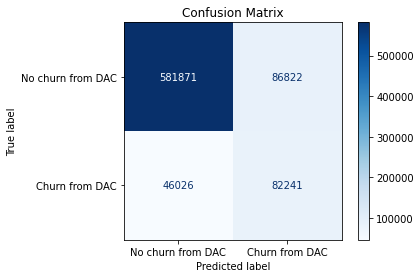

In [23]:
cm = confusion_matrix(t, c)
class_labels = ['No churn from DAC', 'Churn from DAC']
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)
disp.plot(cmap=plt.cm.Blues, values_format='d')
plt.title('Confusion Matrix');

In [24]:
print('Metrics by DAC segment:')
rows = []
for segment, part in df.groupby('segment'):
    if part[target].nunique() < 2:
        continue
    rows.append({
        'segment': segment,
        'rows': len(part),
        'target_rate': part[target].mean(),
        'roc_auc': sk_roc_auc_score(part[target], part[score]),
        'pr_auc': sk_average_precision_score(part[target], part[score]),
        'ap_gain': sk_average_precision_score(part[target], part[score]) - part[target].mean(),
    })

pd.DataFrame(rows).sort_values('pr_auc', ascending=False)

Metrics by DAC segment:


,segment,rows,target_rate,roc_auc,pr_auc,ap_gain
0,new_1m,36967,0.435010,0.796277,0.725590,0.290580
3,unstable_2_5m,146436,0.313789,0.809095,0.619387,0.305598
1,regular_6_9m,163699,0.233337,0.780272,0.478053,0.244716
2,stable_10_12m,449858,0.062329,0.857398,0.268141,0.205812


### 12. Save Artifacts

Artifacts dir: /home/gorelova_i_v/projects/cvm_churn-from-dac_binary-class_churn-dac/src/cvm_model/artifacts


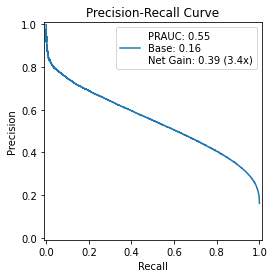

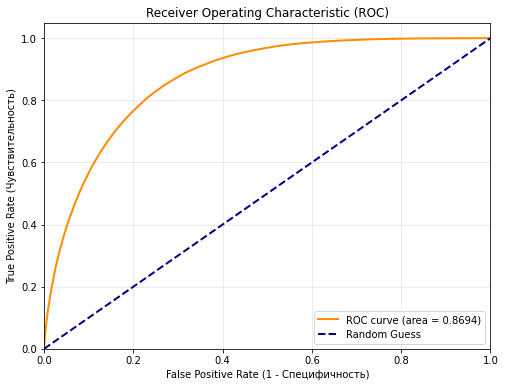

In [25]:
for file in Path(artifacts_dir).iterdir():
    if file.is_file():
        try:
            file.unlink()
        except Exception as e:
            print(f'Failed to delete {file}. Reason: {e}')

func.plot_precision_recall_curve(t, s, artifacts_dir=artifacts_dir)

func.plot_roc(t, s, artifacts_dir=artifacts_dir)

plt.figure(figsize=(8, 6))
sns.histplot(s[t == 0], label='No churn from DAC', kde=True, stat='density', color='blue')
sns.histplot(s[t == 1], label='Churn from DAC', kde=True, stat='density', alpha=0.25, color='orange')
title = 'Labeled Score Histogram'
plt.title(title)
plt.legend()
plt.savefig(os.path.join(artifacts_dir, title), bbox_inches='tight')
plt.close()

cm = confusion_matrix(t, c)
class_labels = ['No churn from DAC', 'Churn from DAC']
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)
disp.plot(cmap=plt.cm.Blues, values_format='d')
title = 'Confusion Matrix'
plt.title(title)
plt.savefig(os.path.join(artifacts_dir, title), bbox_inches='tight')
plt.close()

Path(os.path.join(artifacts_dir, 'features.txt')).write_text('\n'.join(features), encoding='utf-8')

print('Artifacts dir:', Path(artifacts_dir).resolve())

### 13. Log Train Run In MLflow

In [35]:
signature = infer_signature(df.head(1)[features], df.head(1)[score])

description = f'train_{event_timestamp}'

params = {
    'event_timestamp': event_timestamp,
    'threshold': selected_threshold,
    'default_threshold': threshold,
    'features_count': len(features),
    'rows_count': len(df),
    'target_rate': float(df[target].mean()),
}
params

{'event_timestamp': datetime.datetime(2026, 1, 1, 0, 0),
 'threshold': 0.3,
 'default_threshold': 0.3,
 'features_count': 80,
 'rows_count': 796960,
 'target_rate': 0.1609453423007428}

In [ ]:
model_name = f'{project_name}_{model_type}'
experiment_name = f'{model_name}_{jira}_train'

logging.info(experiment_name)
logging.info(model_name)
mlflow.set_experiment(experiment_name)
experiment_name, model_name

In [37]:
with mlflow.start_run(run_name=description, description=description):

    for k, v in params.items():
        mlflow.log_param(k, v)

    for k, v in metrics.items():
        mlflow.log_metric(k, v)

    for root, dirs, files in os.walk(artifacts_dir):
        dirs[:] = [d for d in dirs if d != ".ipynb_checkpoints"]
        for file in files:
            full_path = os.path.join(root, file)
            rel_path = os.path.relpath(root, artifacts_dir)
            artifact_path = rel_path if rel_path != "." else None
            mlflow.log_artifact(full_path)

    mlflow.sklearn.log_model(
        model, 
        name=model_name, 
        signature=signature,
        registered_model_name=model_name,
        tags=params,
    )


client = MlflowClient()
last_version = client.search_model_versions(f"name = '{model_name}'", order_by=["version_number DESC"])[0].version
tags = params
for k, v in tags.items():
    client.set_model_version_tag(name=model_name, version=last_version, key=k, value=v)

Successfully registered model 'cvm_churn-from-dac_binary-class_churn-dac_catboost'.
Created version '1' of model 'cvm_churn-from-dac_binary-class_churn-dac_catboost'.


### 14. Feature Importance

In [ ]:
X_train, X_val, y_train, y_val, z_train, _ = train_test_split(
    df[features],
    df[target],
    df['strat'],
    stratify=df['strat'],
    test_size=0.3,
    random_state=RANDOM_STATE,
)

model.fit(X_train, y_train, plot=False, verbose=1)
predicts_val = model.predict_proba(X_val)[:, 1]

print('Val PR-AUC:', sk_average_precision_score(y_val, predicts_val))
print('Val ROC-AUC:', sk_roc_auc_score(y_val, predicts_val))

Learning rate set to 0.14737
0:	learn: 0.4633791	test: 0.4554952	best: 0.4554952 (0)	total: 81.1ms	remaining: 1m 21s


20:	learn: 0.5396940	test: 0.5306443	best: 0.5306443 (20)	total: 729ms	remaining: 34s
40:	learn: 0.5469319	test: 0.5367716	best: 0.5367716 (40)	total: 1.39s	remaining: 32.6s
60:	learn: 0.5510881	test: 0.5391556	best: 0.5392983 (59)	total: 2.05s	remaining: 31.5s
80:	learn: 0.5544300	test: 0.5403937	best: 0.5404390 (79)	total: 2.69s	remaining: 30.5s
100:	learn: 0.5581733	test: 0.5414358	best: 0.5415940 (96)	total: 3.33s	remaining: 29.7s
120:	learn: 0.5620500	test: 0.5419449	best: 0.5419449 (120)	total: 3.97s	remaining: 28.9s
140:	learn: 0.5653877	test: 0.5418278	best: 0.5420421 (124)	total: 4.6s	remaining: 28s
160:	learn: 0.5686260	test: 0.5421919	best: 0.5422040 (159)	total: 5.25s	remaining: 27.4s
180:	learn: 0.5714469	test: 0.5421457	best: 0.5423524 (168)	total: 5.89s	remaining: 26.7s
200:	learn: 0.5747403	test: 0.5419748	best: 0.5423524 (168)	total: 6.53s	remaining: 26s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.5423524034
bestIteration = 168

Shrink model to 

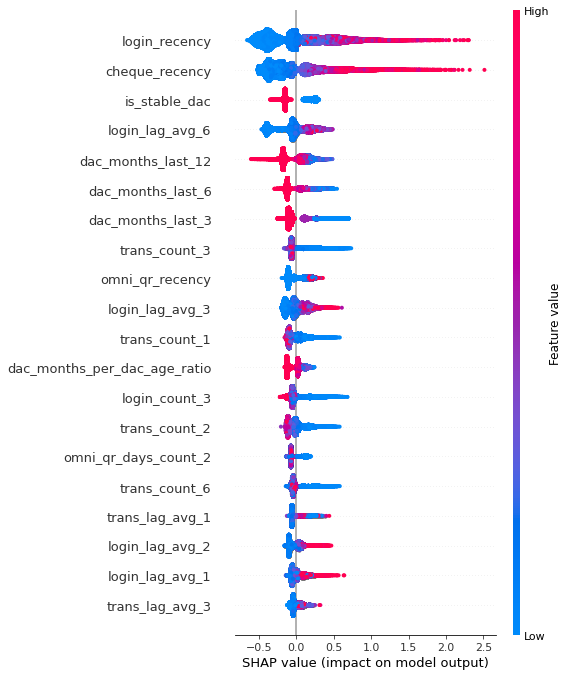

In [ ]:
shap_val_sample_size = min(200_000, len(X_val))
X_val_sample = X_val.sample(shap_val_sample_size, random_state=RANDOM_STATE)
explainer = shap.TreeExplainer(model)
shap_vals_val = explainer.shap_values(X_val_sample)
shap.summary_plot(shap_vals_val, X_val_sample)

In [ ]:
reduntant_filter, pairs = func.get_redundant_features(X_train, threshold=0.85)
print('Redundant features:', len(reduntant_filter))
display(pd.DataFrame(pairs, columns=['feature_1', 'feature_2', 'corr']).head(100))

joblib.dump(reduntant_filter, 'reduntant_filter_churn_from_dac.pkl')

Redundant features: 33


,feature_1,feature_2,corr
0,dac_months_last_6,dac_months_last_12,0.8800
1,is_stable_dac,dac_months_last_12,0.8669
2,login_count_3,login_count_6,0.9632
3,login_count_3,login_count_12,0.8979
4,login_count_6,login_count_12,0.9582
5,trans_count_3,trans_count_2,0.9765
6,omni_qr_days_count_2,omni_qr_days_count_6,0.9067
7,trans_count_3,trans_count_6,0.9519
8,trans_count_2,trans_count_6,0.9128
9,omni_qr_days_count_6,omni_qr_days_count_12,0.9407


['reduntant_filter_churn_from_dac.pkl']

In [ ]:
RUN_PERMUTATION_IMPORTANCE = True

if RUN_PERMUTATION_IMPORTANCE:
    r = permutation_importance(
        model,
        X_val,
        y_val,
        scoring='average_precision',
        n_repeats=10,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    pi_df = pd.DataFrame({
        'feature': X_val.columns,
        'importance_mean': r.importances_mean,
        'importance_std': r.importances_std,
    }).sort_values('importance_mean', ascending=False)
    display(pi_df.head(100))

    pi_filter = pi_df.loc[pi_df['importance_mean'] < 0.0001, 'feature'].tolist()
    joblib.dump(pi_filter, 'pi_filter_churn_from_dac.pkl')

,feature,importance_mean,importance_std
20,login_recency,0.026678,0.000654
34,cheque_recency,0.022688,0.000820
2,dac_months_last_12,0.013363,0.000826
0,dac_months_last_6,0.008036,0.000368
10,dac_months_last_3,0.008019,0.000260
5,login_count_3,0.005402,0.000337
1,is_stable_dac,0.005067,0.000343
37,omni_qr_recency,0.004385,0.000316
21,trans_count_1,0.004022,0.000337
12,trans_count_3,0.003707,0.000394


### 14.1 Feature Set Experiments

Сравниваем несколько вариантов набора признаков:

1. `all_features` — все текущие фичи из `parameters.py`.
2. `top_80_features` — топ-80 по permutation importance, если `pi_df` уже посчитан; иначе fallback на CatBoost feature importance.
3. `no_redundant_features` — удаляем признаки из `reduntant_filter`.
4. `no_dac_segment_features` — убираем DAC-history / DAC-segment признаки.
5. `only_dac_segment_features` — оставляем только DAC-history / DAC-segment признаки.

Каждый эксперимент логируется в MLflow отдельным run. Победителя выбираем по `holdout_pr_auc`.

In [ ]:
# MLflow remote setup. Если URI уже задан окружением, эта ячейка просто зафиксирует его явно.
MLFLOW_TRACKING_URI = os.getenv('MLFLOW_TRACKING_URI') or 'https://mlflow-analytics.cvm-prod.corp.tander.ru'
mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)

print('MLflow tracking URI:', mlflow.get_tracking_uri())
print('MLFLOW_TRACKING_USERNAME exists:', bool(os.getenv('MLFLOW_TRACKING_USERNAME')))
print('MLFLOW_TRACKING_PASSWORD exists:', bool(os.getenv('MLFLOW_TRACKING_PASSWORD')))

In [ ]:
def get_top_features_by_importance(base_features, top_n=80):
    base_features = list(dict.fromkeys(base_features))

    if 'pi_df' in globals() and isinstance(pi_df, pd.DataFrame) and {'feature', 'importance_mean'} <= set(pi_df.columns):
        top_features = (
            pi_df[pi_df['feature'].isin(base_features)]
            .sort_values('importance_mean', ascending=False)['feature']
            .head(top_n)
            .tolist()
        )
        source = 'permutation_importance'
    else:
        try:
            fi_df = pd.DataFrame({
                'feature': base_features,
                'importance': model.get_feature_importance(),
            }).sort_values('importance', ascending=False)
            top_features = fi_df['feature'].head(top_n).tolist()
            source = 'catboost_feature_importance'
        except Exception:
            top_features = base_features[:top_n]
            source = 'original_order_fallback'

    return top_features, source


def get_dac_segment_features(base_features):
    # DAC-history / segment фичи. Это не leakage, если они посчитаны только до target_month.
    dac_exact = {
        'dac_age_months',
        'dac_months_count',
        'dac_months_per_dac_age_ratio',
        'dac_months_last_3',
        'dac_months_last_6',
        'dac_months_last_12',
        'dac_share_last_12',
        'is_stable_dac',
        'is_regular_dac',
        'is_unstable_dac',
        'is_new_dac',
        'segment',
        'dac_segment_12m',
    }
    return [f for f in base_features if f in dac_exact or f.startswith('dac_') or f.endswith('_dac') or f.startswith('is_') and f.endswith('_dac')]


base_features = [f for f in list(dict.fromkeys(features)) if f in df.columns and f in holdout_df.columns]
top_80_features, top_80_source = get_top_features_by_importance(base_features, top_n=80)
redundant_features = [f for f in globals().get('reduntant_filter', []) if f in base_features]
dac_segment_features = get_dac_segment_features(base_features)

feature_sets = {
    '01_all_features': base_features,
    '02_top_80_features': top_80_features,
    '03_no_redundant_features': [f for f in base_features if f not in redundant_features],
    '04_no_dac_segment_features': [f for f in base_features if f not in dac_segment_features],
    '05_only_dac_segment_features': dac_segment_features,
}

feature_sets = {name: list(dict.fromkeys(cols)) for name, cols in feature_sets.items()}

feature_set_summary = pd.DataFrame([
    {'feature_set': name, 'features_count': len(cols), 'features': ', '.join(cols[:20]) + (' ...' if len(cols) > 20 else '')}
    for name, cols in feature_sets.items()
])

print('Top-80 source:', top_80_source)
print('Redundant features:', len(redundant_features))
print('DAC segment/history features:', len(dac_segment_features), dac_segment_features)
display(feature_set_summary)

assert len(feature_sets['05_only_dac_segment_features']) > 0, 'Не нашлись DAC segment/history фичи'

In [ ]:
def fbeta_threshold(y_true, y_score, beta=1.0):
    scores = {}
    for thr in np.arange(0.05, 1.0, 0.05):
        scores[thr] = fbeta_score(y_true, y_score > thr, beta=beta)
    return max(scores.items(), key=lambda x: x[1])[0]


def decile_report(data, score_col, target_col):
    tmp = data[[score_col, target_col]].copy()
    tmp['score_decile'] = pd.qcut(
        tmp[score_col].rank(method='first'),
        q=10,
        labels=False,
        duplicates='drop',
    ) + 1
    return tmp.groupby('score_decile').agg(
        rows=(target_col, 'size'),
        target_rate=(target_col, 'mean'),
        score_min=(score_col, 'min'),
        score_max=(score_col, 'max'),
    ).sort_index(ascending=False)


def calculate_binary_metrics(y_true, y_score, threshold_value):
    y_pred = y_score > threshold_value
    return {
        'roc_auc': float(sk_roc_auc_score(y_true, y_score)),
        'pr_auc': float(sk_average_precision_score(y_true, y_score)),
        'ap_gain': float(sk_average_precision_score(y_true, y_score) - np.mean(y_true)),
        'threshold': float(threshold_value),
        'predicted_positive_share': float(np.mean(y_pred)),
        'precision': float(precision_score(y_true, y_pred)),
        'recall': float(recall_score(y_true, y_pred)),
        'f1': float(f1_score(y_true, y_pred)),
        'f05': float(fbeta_score(y_true, y_pred, beta=0.5)),
        'f2': float(fbeta_score(y_true, y_pred, beta=2)),
        'brier': float(sk_brier_score_loss(y_true, y_score)),
    }


def train_score_feature_set(feature_set_name, feature_cols, model_params=None, log_to_mlflow=True):
    feature_cols = list(dict.fromkeys([f for f in feature_cols if f in df.columns and f in holdout_df.columns]))
    assert len(feature_cols) > 0, f'Пустой список фичей для {feature_set_name}'

    params_model = {
        'random_state': RANDOM_STATE,
        'use_best_model': True,
        'metric_period': 20,
        'eval_metric': 'PRAUC',
        'eval_fraction': 0.1,
        'early_stopping_rounds': 50,
        'thread_count': -1,
        'verbose': -1,
    }
    if model_params:
        params_model.update(model_params)

    exp_model = CatBoostClassifier(**params_model)
    exp_model.fit(df[feature_cols], df[target], plot=False, verbose=0)

    train_score_col = f'{score}_{feature_set_name}_train'
    holdout_score_col = f'{score}_{feature_set_name}'

    df[train_score_col] = exp_model.predict_proba(df[feature_cols])[:, 1]
    holdout_df[holdout_score_col] = exp_model.predict_proba(holdout_df[feature_cols])[:, 1]

    selected_thr = fbeta_threshold(df[target], df[train_score_col], beta=1)
    train_metrics = calculate_binary_metrics(df[target], df[train_score_col], selected_thr)
    holdout_metrics = calculate_binary_metrics(holdout_df[target], holdout_df[holdout_score_col], selected_thr)

    deciles = decile_report(holdout_df, holdout_score_col, target)
    top_decile_target_rate = float(deciles.iloc[0]['target_rate'])
    top_decile_lift = float(top_decile_target_rate / holdout_df[target].mean())

    segment_rows = []
    for segment_name, part in holdout_df.groupby('segment'):
        if part[target].nunique() < 2:
            continue
        segment_rows.append({
            'segment': segment_name,
            'rows': len(part),
            'target_rate': float(part[target].mean()),
            'pr_auc': float(sk_average_precision_score(part[target], part[holdout_score_col])),
            'roc_auc': float(sk_roc_auc_score(part[target], part[holdout_score_col])),
        })
    segment_metrics = pd.DataFrame(segment_rows)

    row = {
        'feature_set': feature_set_name,
        'features_count': len(feature_cols),
        'train_pr_auc': train_metrics['pr_auc'],
        'holdout_pr_auc': holdout_metrics['pr_auc'],
        'holdout_roc_auc': holdout_metrics['roc_auc'],
        'holdout_ap_gain': holdout_metrics['ap_gain'],
        'holdout_f1': holdout_metrics['f1'],
        'holdout_precision': holdout_metrics['precision'],
        'holdout_recall': holdout_metrics['recall'],
        'threshold': selected_thr,
        'top_decile_target_rate': top_decile_target_rate,
        'top_decile_lift': top_decile_lift,
    }

    if log_to_mlflow:
        experiment_name = f'{project_name}_{model_type}_{jira}_feature_selection'
        mlflow.set_experiment(experiment_name)
        run_name = f'{feature_set_name}_{base_month}_features_{len(feature_cols)}'

        features_file = f'features_{feature_set_name}.txt'
        deciles_file = f'deciles_{feature_set_name}.csv'
        segments_file = f'segment_metrics_{feature_set_name}.csv'
        model_file = f'model_{feature_set_name}.cbm'

        Path(features_file).write_text('\n'.join(feature_cols), encoding='utf-8')
        deciles.to_csv(deciles_file)
        segment_metrics.to_csv(segments_file, index=False)
        exp_model.save_model(model_file)

        with mlflow.start_run(run_name=run_name, description=f'Feature set experiment: {feature_set_name}'):
            mlflow.log_param('base_month', base_month)
            mlflow.log_param('target_month', target_month)
            mlflow.log_param('feature_set', feature_set_name)
            mlflow.log_param('features_count', len(feature_cols))
            mlflow.log_param('top_80_source', top_80_source)
            mlflow.log_param('removed_redundant_features_count', len(redundant_features) if feature_set_name == '03_no_redundant_features' else 0)
            mlflow.log_param('dac_segment_features_count', len(dac_segment_features))
            mlflow.log_param('threshold', selected_thr)

            for k, v in params_model.items():
                if isinstance(v, (str, int, float, bool)) or v is None:
                    mlflow.log_param(f'catboost_{k}', v)

            for k, v in row.items():
                if k not in {'feature_set'}:
                    mlflow.log_metric(k, float(v))

            for _, seg_row in segment_metrics.iterrows():
                seg = str(seg_row['segment']).replace('-', '_').replace(' ', '_')
                mlflow.log_metric(f'segment_{seg}_pr_auc', float(seg_row['pr_auc']))
                mlflow.log_metric(f'segment_{seg}_roc_auc', float(seg_row['roc_auc']))

            mlflow.log_artifact(features_file)
            mlflow.log_artifact(deciles_file)
            mlflow.log_artifact(segments_file)
            mlflow.log_artifact(model_file)

        for local_file in [features_file, deciles_file, segments_file, model_file]:
            try:
                Path(local_file).unlink()
            except FileNotFoundError:
                pass

    return row, exp_model, feature_cols, deciles, segment_metrics

In [ ]:
RUN_FEATURE_SET_EXPERIMENTS = True

feature_experiment_rows = []
feature_experiment_models = {}
feature_experiment_features = {}
feature_experiment_deciles = {}
feature_experiment_segments = {}

if RUN_FEATURE_SET_EXPERIMENTS:
    for feature_set_name, feature_cols in feature_sets.items():
        print(f'\n=== {feature_set_name}: {len(feature_cols)} features ===')
        row, exp_model, used_features, deciles, segment_metrics = train_score_feature_set(
            feature_set_name,
            feature_cols,
            model_params=None,
            log_to_mlflow=True,
        )
        feature_experiment_rows.append(row)
        feature_experiment_models[feature_set_name] = exp_model
        feature_experiment_features[feature_set_name] = used_features
        feature_experiment_deciles[feature_set_name] = deciles
        feature_experiment_segments[feature_set_name] = segment_metrics
        display(pd.DataFrame([row]))

feature_experiment_results = pd.DataFrame(feature_experiment_rows).sort_values('holdout_pr_auc', ascending=False)
display(feature_experiment_results)

best_feature_set_name = feature_experiment_results.iloc[0]['feature_set']
best_feature_set_features = feature_experiment_features[best_feature_set_name]
best_feature_set_model = feature_experiment_models[best_feature_set_name]

print('Best feature set:', best_feature_set_name)
print('Best features count:', len(best_feature_set_features))
print('Best holdout PR-AUC:', feature_experiment_results.iloc[0]['holdout_pr_auc'])

### 14.2 Optuna Tuning For Best Feature Set

Тюним CatBoost только на лучшем наборе фичей из предыдущего блока. Так мы не смешиваем два процесса: сначала выбираем представление данных, потом оптимизируем параметры модели.

In [ ]:
# Если optuna не установлена в kernel, один раз выполни:
# %pip install optuna

import optuna

In [ ]:
RUN_OPTUNA_TUNING = True
N_TRIALS = 30
OPTUNA_TIMEOUT = None  # например, 60 * 60 для ограничения в 1 час

X_train_tune, X_val_tune, y_train_tune, y_val_tune, z_train_tune, _ = train_test_split(
    df[best_feature_set_features],
    df[target],
    df['strat'],
    stratify=df['strat'],
    test_size=0.25,
    random_state=RANDOM_STATE,
)


def objective(trial):
    params_trial = {
        'random_state': RANDOM_STATE,
        'loss_function': 'Logloss',
        'eval_metric': 'PRAUC',
        'iterations': trial.suggest_int('iterations', 300, 1200),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.15, log=True),
        'depth': trial.suggest_int('depth', 4, 10),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1.0, 30.0, log=True),
        'random_strength': trial.suggest_float('random_strength', 0.1, 10.0, log=True),
        'border_count': trial.suggest_categorical('border_count', [64, 128, 254]),
        'early_stopping_rounds': 50,
        'thread_count': -1,
        'verbose': False,
    }

    bootstrap_type = trial.suggest_categorical('bootstrap_type', ['Bayesian', 'Bernoulli', 'MVS'])
    params_trial['bootstrap_type'] = bootstrap_type

    if bootstrap_type == 'Bayesian':
        params_trial['bagging_temperature'] = trial.suggest_float('bagging_temperature', 0.0, 5.0)
    else:
        params_trial['subsample'] = trial.suggest_float('subsample', 0.6, 1.0)

    tune_model = CatBoostClassifier(**params_trial)
    tune_model.fit(
        X_train_tune,
        y_train_tune,
        eval_set=(X_val_tune, y_val_tune),
        use_best_model=True,
        verbose=False,
    )

    val_pred = tune_model.predict_proba(X_val_tune)[:, 1]
    return sk_average_precision_score(y_val_tune, val_pred)


if RUN_OPTUNA_TUNING:
    study = optuna.create_study(
        direction='maximize',
        study_name=f'catboost_{best_feature_set_name}_churn_from_dac_pr_auc',
    )
    study.optimize(objective, n_trials=N_TRIALS, timeout=OPTUNA_TIMEOUT, show_progress_bar=True)

    print('Best Optuna validation PR-AUC:', study.best_value)
    print('Best params:')
    display(study.best_params)
else:
    study = None

In [ ]:
if RUN_OPTUNA_TUNING:
    best_catboost_params = {
        'random_state': RANDOM_STATE,
        'loss_function': 'Logloss',
        'eval_metric': 'PRAUC',
        'early_stopping_rounds': 50,
        'thread_count': -1,
        'verbose': False,
        **study.best_params,
    }

    tuned_feature_set_name = f'06_optuna_{best_feature_set_name}'
    tuned_row, tuned_model, tuned_features, tuned_deciles, tuned_segment_metrics = train_score_feature_set(
        tuned_feature_set_name,
        best_feature_set_features,
        model_params=best_catboost_params,
        log_to_mlflow=True,
    )

    feature_experiment_results = pd.concat(
        [feature_experiment_results, pd.DataFrame([tuned_row])],
        ignore_index=True,
    ).sort_values('holdout_pr_auc', ascending=False)

    feature_experiment_models[tuned_feature_set_name] = tuned_model
    feature_experiment_features[tuned_feature_set_name] = tuned_features
    feature_experiment_deciles[tuned_feature_set_name] = tuned_deciles
    feature_experiment_segments[tuned_feature_set_name] = tuned_segment_metrics

    print('Final feature experiment results:')
    display(feature_experiment_results)

    final_best_feature_set_name = feature_experiment_results.iloc[0]['feature_set']
    final_best_features = feature_experiment_features[final_best_feature_set_name]
    final_best_model = feature_experiment_models[final_best_feature_set_name]

    print('Final best feature set:', final_best_feature_set_name)
    print('Final best features count:', len(final_best_features))
    print('Final best holdout PR-AUC:', feature_experiment_results.iloc[0]['holdout_pr_auc'])

    joblib.dump(study.best_params, 'best_catboost_params_churn_from_dac.pkl')
    final_best_model.save_model('best_feature_set_model_churn_from_dac.cbm')
    Path('best_feature_set_features.txt').write_text('\n'.join(final_best_features), encoding='utf-8')
else:
    final_best_feature_set_name = best_feature_set_name
    final_best_features = best_feature_set_features
    final_best_model = best_feature_set_model

In [ ]:
interactions = model.get_feature_importance(type='Interaction')
interaction_df = pd.DataFrame(interactions, columns=['f1', 'f2', 'score'])
interaction_df['f1_name'] = interaction_df['f1'].apply(lambda x: features[int(x)])
interaction_df['f2_name'] = interaction_df['f2'].apply(lambda x: features[int(x)])
top_interactions = interaction_df.sort_values(by='score', ascending=False).head(15)
display(top_interactions[['f1_name', 'f2_name', 'score']])

,f1_name,f2_name,score
0,trans_count_1,cheque_recency,0.807410
1,login_lag_avg_3,login_recency,0.795401
2,login_recency,cheque_recency,0.765166
3,login_recency,login_lag_avg_12,0.645578
4,bonus_accrued_sum_1,population_avg_24,0.629031
5,login_lag_avg_6,login_recency,0.456205
6,login_lag_avg_3,login_lag_avg_1,0.455712
7,cheque_recency,login_lag_avg_1,0.454921
8,login_count_3,login_recency,0.454223
9,login_recency,omni_qr_recency,0.435448


### 15. Save Scored Dataset

In [ ]:
scored_path = f'df_churn_from_dac_scored_{event_timestamp}.parquet'
df.to_parquet(scored_path, index=False)
print(scored_path)

if holdout_df is not None:
    holdout_scored_path = f'holdout_churn_from_dac_scored_{event_timestamp}.parquet'
    holdout_df.to_parquet(holdout_scored_path, index=False)
    print(holdout_scored_path)

df_churn_from_dac_scored_2026-01-01.parquet
holdout_churn_from_dac_scored_2026-01-01.parquet


### 16. Experiment Report

In [ ]:
experiment_report = {
    'event_timestamp': event_timestamp,
    'target': target,
    'rows': len(df),
    'target_rate': df[target].mean(),
    'features_count': len(features),
    'selected_threshold': selected_threshold if 'selected_threshold' in globals() else None,
    'catboost_pr_auc': float(metrics['PR-AUC']) if 'metrics' in globals() else None,
    'catboost_roc_auc': float(metrics['ROC-AUC']) if 'metrics' in globals() else None,
}

print('Experiment report:')
display(pd.DataFrame(experiment_report, index=['value']).T)

print('Top CatBoost feature importances:')
try:
    fi = pd.DataFrame({
        'feature': features,
        'importance': model.get_feature_importance(),
    }).sort_values('importance', ascending=False)
    display(fi.head(30))
except Exception as e:
    print('Feature importance is not available yet:', e)

Experiment report:


,value
event_timestamp,2026-01-01
target,target_churn_from_dac
rows,800000
target_rate,0.160571
features_count,80
selected_threshold,0.3
baseline_best_pr_auc,0.547769
catboost_pr_auc,0.547309
catboost_roc_auc,0.869736


Top CatBoost feature importances:


,feature,importance
20,login_recency,14.872427
34,cheque_recency,8.863007
3,login_lag_avg_6,8.193033
1,is_stable_dac,5.495810
21,trans_count_1,5.115910
4,login_lag_avg_3,4.575334
2,dac_months_last_12,3.489599
0,dac_months_last_6,3.412477
12,trans_count_3,3.138115
5,login_count_3,2.799096
